<h1>Train — ResNet-18 (baseline)</h1>

Trains and evaluates the ResNet-18 baseline classifier, then saves its results (`results_resnet18.pkl`) and weights (`{COMPONENT}_resnet18_cnn.pt`) to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): NoordelikeWerke
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1692 | Val: 410 | Test: 405


## Define the model (Transfer Learning with ResNet-18)

In [2]:
model_resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_ftrs = model_resnet18.fc.in_features
model_resnet18.fc = nn.Linear(num_ftrs, num_classes)  # no hidden layers — this one predates the tuning sweep

model_resnet18 = model_resnet18.to(device)

# ---------------------------------------------------------
# Loss and optimizer, with class weights for the imbalanced classes
# ---------------------------------------------------------
class_weights = make_class_weights(train_ds)
print("Applying class weights to loss function:")
for name, w in zip(class_names, class_weights.cpu().numpy()):
    print(f"  {name:<15s}: {w:.3f}")

criterion_resnet18 = nn.CrossEntropyLoss(weight=class_weights)
optimizer_resnet18 = optim.Adam(model_resnet18.parameters(), lr=5e-4, weight_decay=WEIGHT_DECAY)

# mode='min' because we want to minimize loss; factor=0.5 halves the LR when
# triggered; patience=3 waits 3 epochs with no improvement before reducing it
scheduler_resnet18 = ReduceLROnPlateau(optimizer_resnet18, mode='min', factor=0.5, patience=3)

Applying class weights to loss function:
  Dysfunctional  : 2.097
  Empty          : 1.249
  Functional     : 0.320
  Scum           : 0.333


## Train, then plot training curves

[ResNet-18] Epoch   1/100 | LR: 5.00e-04 | train loss 0.8005 acc 0.660 | val loss 0.6811 acc 0.759 *


[ResNet-18] Epoch   2/100 | LR: 5.00e-04 | train loss 0.4891 acc 0.785 | val loss 0.4706 acc 0.802 *


[ResNet-18] Epoch   3/100 | LR: 5.00e-04 | train loss 0.4295 acc 0.802 | val loss 0.5404 acc 0.773


[ResNet-18] Epoch   4/100 | LR: 5.00e-04 | train loss 0.3462 acc 0.859 | val loss 0.4596 acc 0.817 *


[ResNet-18] Epoch   5/100 | LR: 5.00e-04 | train loss 0.2688 acc 0.884 | val loss 0.5997 acc 0.771


...

[ResNet-18] Epoch  15/100 | LR: 1.25e-04 | train loss 0.0025 acc 1.000 | val loss 0.4851 acc 0.876


[ResNet-18] Epoch  16/100 | LR: 1.25e-04 | train loss 0.0019 acc 1.000 | val loss 0.4910 acc 0.868


[ResNet-18] Epoch  17/100 | LR: 6.25e-05 | train loss 0.0020 acc 1.000 | val loss 0.4907 acc 0.871


[ResNet-18] Epoch  18/100 | LR: 6.25e-05 | train loss 0.0021 acc 1.000 | val loss 0.5117 acc 0.871


[ResNet-18] Epoch  19/100 | LR: 6.25e-05 | train loss 0.0041 acc 0.998 | val loss 0.5740 acc 0.859

[ResNet-18] No val loss improvement for 10 epochs — stopping early at epoch 19.

[ResNet-18] Restored best checkpoint (val loss = 0.3725)


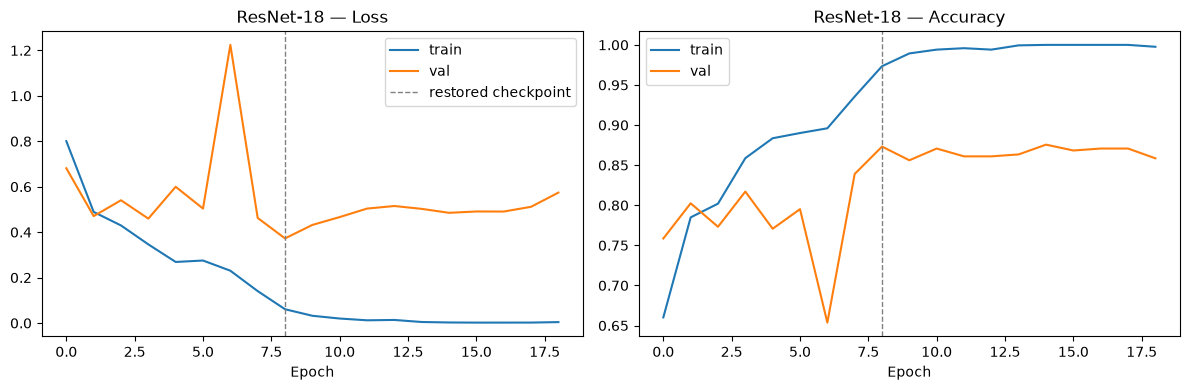

In [3]:
history_resnet18 = train_model(
    model_resnet18, train_loader, val_loader, optimizer_resnet18, scheduler_resnet18,
    criterion_resnet18, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18",
)
plot_training_curves(history_resnet18, "ResNet-18")

## Evaluate on the test set

[ResNet-18] Test accuracy: 0.802


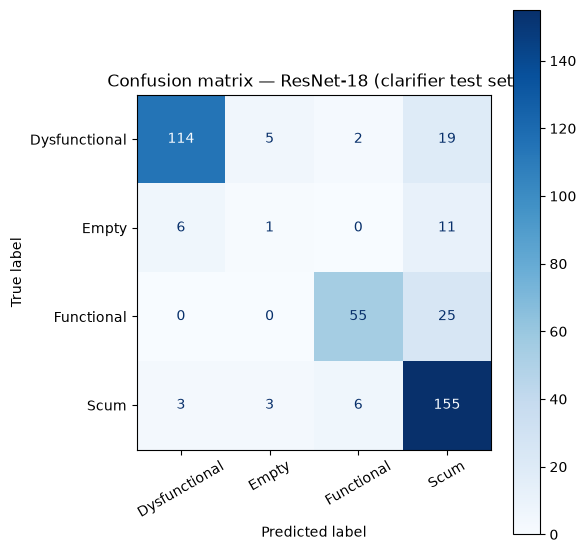

               precision    recall  f1-score   support

Dysfunctional      0.927     0.814     0.867       140
        Empty      0.111     0.056     0.074        18
   Functional      0.873     0.688     0.769        80
         Scum      0.738     0.928     0.822       167

     accuracy                          0.802       405
    macro avg      0.662     0.621     0.633       405
 weighted avg      0.802     0.802     0.794       405



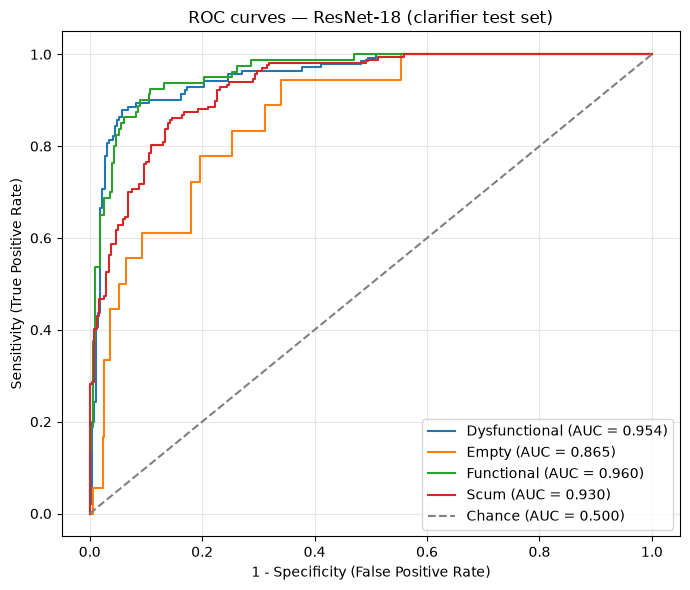

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.954
  Empty          : 0.865
  Functional     : 0.960
  Scum           : 0.930

Mean AUC (over 4/4 classes with test examples): 0.927


(np.float64(0.8024691358024691),
 {'Dysfunctional': 0.9540700808625338,
  'Empty': 0.8650588573069193,
  'Functional': 0.9603846153846154,
  'Scum': 0.9304080913802646})

In [4]:
evaluate_and_record(
    model_resnet18, test_loader, "ResNet-18", history_resnet18,
    img_size=IMG_TARGET_SIZE, hidden_layers=0, neurons=None,
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [5]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/results_clarifier_resnet18_NoordelikeWerke.pkl


Saved model weights to ../models/clarifier_resnet18_cnn.pt
